In [6]:
import pickle
from edautils import *

In [ ]:
on_target_cwce_path = '../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_ctype_label_mincpg_4_minlen_10_postfiltered_min_length_50_soft_labels_ontarget'
cwce_path =  '../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_ctype_label_mincpg_4_minlen_10_postfiltered_min_length_50_soft_labels'
cwce_without_pooling = '../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_ctype_label_mincpg_4_minlen_10_postfiltered_min_length_50_soft_labels_wpooling'
ce_hard = '../Tutorials/methylBertLoyferWithReject_attentionClassifier_DMRs_stratified_hg38_dmr_ctype_label_mincpg_4_minlen_10'
with open(f"{on_target_cwce_path}/predictions_test.pkl", "rb") as f:
    res_on_target = pickle.load(f)
with open(f"{cwce_path}/predictions_test.pkl", "rb") as f:
    res_cwce = pickle.load(f)
with open(f"{cwce_without_pooling}/predictions_test.pkl", "rb") as f:
    res_cwce_wp = pickle.load(f)
with open(f"{ce_hard}/predictions_test.pkl", "rb") as f:
    res_ce_hard = pickle.load(f)

In [25]:
reads_data_path = '/home/luna.kuleuven.be/u0169940/Data/Loyfer/SoftLabelsTrainingData_hg38_mincpg_4_minlen_10/'
reads_data_path_hard = '/home/luna.kuleuven.be/u0169940/Data/Loyfer/TrainingDataWithRejection_hg38_mincpg_4_minlen_10'
reads_data_path_wpolling = '/home/luna.kuleuven.be/u0169940/Data/Loyfer/SoftLabelsTrainingData_withoutpooling_hg38_mincpg_4_minlen_10/'
test_pooled = pd.read_parquet(reads_data_path+f"/test.parquet")
test_hard = pd.read_parquet(reads_data_path_hard+f"/test.parquet")
test_wpooling = pd.read_parquet(reads_data_path_wpolling+f"/test.parquet")


In [ ]:
reads_data_path_hard = '/home/luna.kuleuven.be/u0169940/Data/Loyfer/TrainingDataWithRejection_hg38_mincpg_4_minlen_10'

In [10]:
labels_dict = {int(value["dmr_ctype_label"]):key for (key,value) in test_pooled[["dmr_ctype_label", "dmr_ctype"]].groupby("dmr_ctype").mean().to_dict(orient="index").items()}

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def compute_soft_calibration(preds, targets, n_bins=15):
    rmse = np.sqrt(np.mean((preds - targets) ** 2))
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_indices = np.digitize(preds, bins) - 1
    bin_indices[bin_indices == n_bins] = n_bins - 1
    
    bin_mean_preds, bin_mean_targets, bin_counts = [], [], []
    ece = 0.0
    mce = 0.0  # Track Maximum Calibration Error
    
    total_samples = len(preds)
    
    for b in range(n_bins):
        mask = (bin_indices == b)
        count = np.sum(mask)
        bin_counts.append(count)
        
        if count > 0:
            mean_pred = preds[mask].mean()
            mean_target = targets[mask].mean()
            
            bin_mean_preds.append(mean_pred)
            bin_mean_targets.append(mean_target)
            
            # Absolute error for this specific bin
            bin_error = np.abs(mean_pred - mean_target)
            
            # cwECE Accumulation
            ece += (count / total_samples) * bin_error
            
            # MCE Update (worst-case bin)
            if bin_error > mce:
                mce = bin_error
        else:
            bin_mean_preds.append(np.nan)
            bin_mean_targets.append(np.nan)
            
    return {
        "mean_preds": np.array(bin_mean_preds),
        "mean_targets": np.array(bin_mean_targets),
        "counts": np.array(bin_counts),
        "ece": ece,
        "mce": mce,
        "rmse": rmse
    }

def compute_hard_calibration(preds, binary_targets, n_bins=15):
    brier_score = np.mean((preds - binary_targets) ** 2)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_indices = np.digitize(preds, bins) - 1
    bin_indices[bin_indices == n_bins] = n_bins - 1  
    
    bin_confidences, bin_accuracies, bin_counts = [], [], []
    ece = 0.0
    mce = 0.0 # Track Maximum Calibration Error
    
    total_samples = len(preds)
    
    for b in range(n_bins):
        mask = (bin_indices == b)
        count = np.sum(mask)
        bin_counts.append(count)
        
        if count > 0:
            mean_conf = preds[mask].mean()
            empirical_acc = binary_targets[mask].mean()
            
            bin_confidences.append(mean_conf)
            bin_accuracies.append(empirical_acc)
            
            bin_error = np.abs(mean_conf - empirical_acc)
            ece += (count / total_samples) * bin_error
            
            if bin_error > mce:
                mce = bin_error
        else:
            bin_confidences.append(np.nan)
            bin_accuracies.append(np.nan)
            
    return {
        "mean_preds": np.array(bin_confidences),
        "accuracies": np.array(bin_accuracies),
        "counts": np.array(bin_counts),
        "ece": ece,
        "mce": mce,
        "brier_score": brier_score
    }

def plot_reliability_diagrams(all_preds, all_targets, class_indices, labels_dict=None, n_bins=15, main_title=""):
    num_plots = len(class_indices)
    cols = min(3, num_plots)
    rows = int(np.ceil(num_plots / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
        
    for i, cls_idx in enumerate(class_indices):
        ax = axes[i]
        
        if isinstance(cls_idx, range):
            # Concatenate all classes (Marginal Calibration over all classes)
            preds = np.concatenate([all_preds[:, j] for j in cls_idx])
            targets = np.concatenate([all_targets[:, j] for j in cls_idx])
            class_name = f"Class range({cls_idx.start}, {cls_idx.stop})"
        else:
            preds = all_preds[:, cls_idx]
            targets = all_targets[:, cls_idx]
            class_name = labels_dict.get(cls_idx, f"Class {cls_idx}") if labels_dict else f"Class {cls_idx}"
        
        calib_data = compute_soft_calibration(preds, targets, n_bins=n_bins)
        
        ece = calib_data["ece"]
        mce = calib_data["mce"]
        rmse = calib_data["rmse"]
        mean_preds = calib_data["mean_preds"]
        mean_targets = calib_data["mean_targets"]
        
        ax.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated", zorder=1)
        
        valid = ~np.isnan(mean_preds)
        ax.plot(mean_preds[valid], mean_targets[valid], "s-", color="dodgerblue", 
                linewidth=2, markersize=6, label="Model Output", zorder=2)
        
        # Display cwECE and MCE
        ax.set_title(f"{main_title}\n{class_name}\ncwECE: {ece:.4f} | MCE: {mce:.4f} | RMSE: {rmse:.4f}", fontweight="bold")
        ax.set_xlabel("Mean Predicted Confidence")
        ax.set_ylabel("Mean Target Probability")
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.0])
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.legend(loc="upper left")
        
        ax2 = ax.twinx()
        ax2.bar(np.linspace(0, 1, n_bins), calib_data["counts"], width=1/n_bins, 
                alpha=0.2, color="gray", align="edge")
        ax2.set_ylabel("Number of Reads (Histogram)", color="gray", fontsize=9)
        ax2.set_ylim([0, max(calib_data["counts"]) * 4]) 
        ax2.tick_params(axis='y', labelcolor="gray", labelsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
        
    plt.tight_layout()
    plt.show()

def plot_hard_reliability_diagrams(all_preds, all_hard_targets, class_indices, labels_dict=None, n_bins=15, main_title=""):
    num_plots = len(class_indices)
    cols = min(3, num_plots)
    rows = int(np.ceil(num_plots / cols))
    
    if all_hard_targets.ndim == 2:
        all_hard_targets = np.argmax(all_hard_targets, axis=-1)
    
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
        
    for i, cls_idx in enumerate(class_indices):
        ax = axes[i]
        
        if isinstance(cls_idx, range):
            binary_targets = []
            preds = []
            for j in cls_idx:
                preds.extend(all_preds[:, j])
                binary_targets.extend((all_hard_targets == j).astype(float))
            preds = np.array(preds)
            binary_targets = np.array(binary_targets)
            class_name = f"Class range({cls_idx.start}, {cls_idx.stop})"
        else:
            preds = all_preds[:, cls_idx]
            binary_targets = (all_hard_targets == cls_idx).astype(float)
            class_name = labels_dict.get(cls_idx, f"Class {cls_idx}") if labels_dict else f"Class {cls_idx}"
        
        calib_data = compute_hard_calibration(preds, binary_targets, n_bins=n_bins)
        
        ece = calib_data["ece"]
        mce = calib_data["mce"]
        brier = calib_data["brier_score"]
        mean_preds = calib_data["mean_preds"]
        accuracies = calib_data["accuracies"]
        
        ax.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated", zorder=1)
        
        valid = ~np.isnan(mean_preds)
        ax.plot(mean_preds[valid], accuracies[valid], "s-", color="crimson", 
                linewidth=2, markersize=6, label="Model Output", zorder=2)
        
        # Display cwECE and MCE
        ax.set_title(f"{main_title}\n{class_name}\ncwECE: {ece:.4f} | MCE: {mce:.4f} | Brier: {brier:.4f}", fontweight="bold")
        ax.set_xlabel("Mean Predicted Confidence")
        ax.set_ylabel("Empirical Accuracy (Fraction of Positives)")
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.0])
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.legend(loc="upper left")
        
        ax2 = ax.twinx()
        ax2.bar(np.linspace(0, 1, n_bins), calib_data["counts"], width=1/n_bins, 
                alpha=0.2, color="gray", align="edge")
        ax2.set_ylabel("Number of Reads (Histogram)", color="gray", fontsize=9)
        ax2.set_ylim([0, max(calib_data["counts"]) * 4]) 
        ax2.tick_params(axis='y', labelcolor="gray", labelsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
        
    plt.tight_layout()
    plt.show()

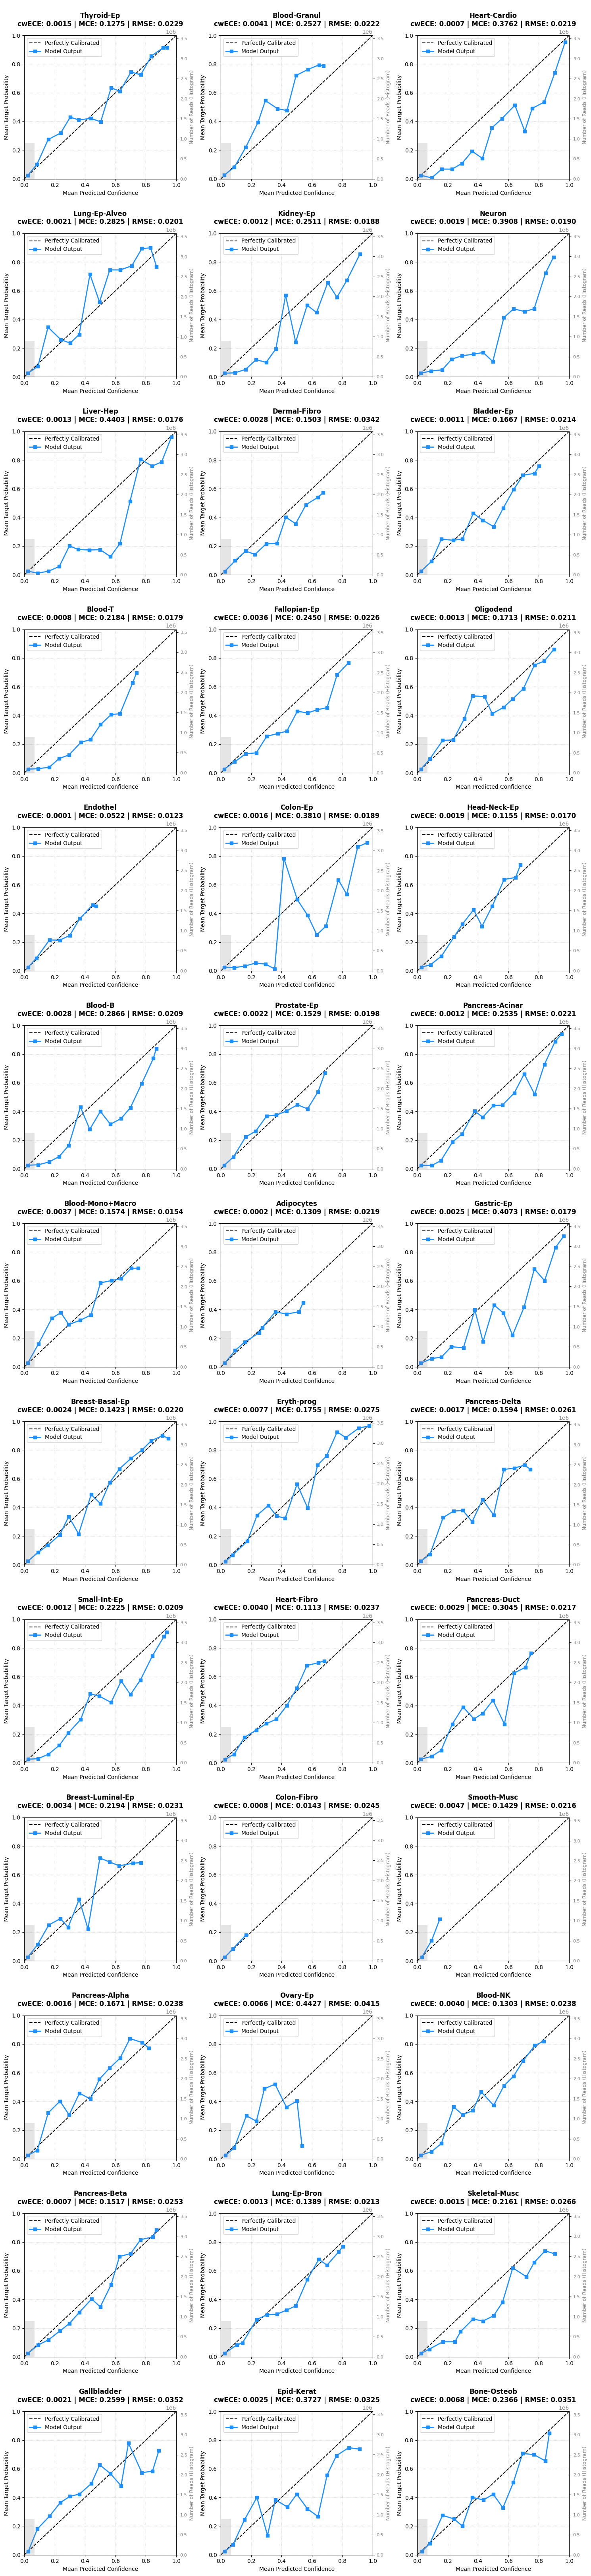

In [77]:
plot_reliability_diagrams(res_cwce[0], res_cwce[1], list(range(39)), labels_dict=labels_dict)

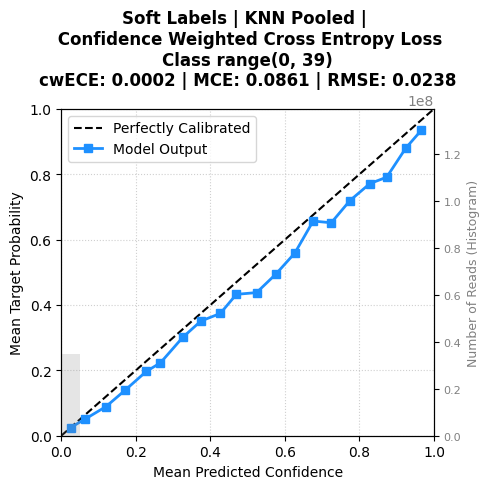

In [78]:
plot_reliability_diagrams(res_cwce[0], res_cwce[1], [range(39)], labels_dict=labels_dict, main_title="Soft Labels | KNN Pooled | \n Confidence Weighted Cross Entropy Loss", n_bins=20)

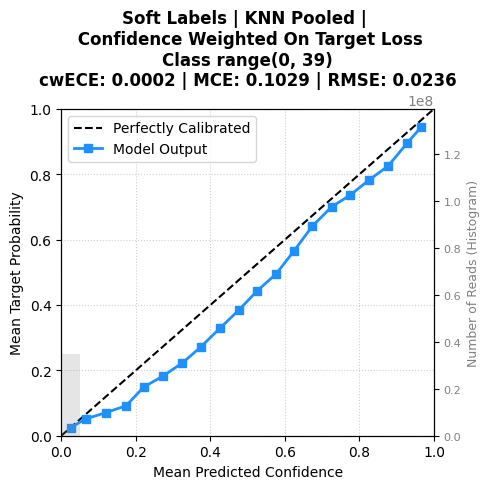

In [79]:
plot_reliability_diagrams(res_on_target[0], res_on_target[1], [range(39)], labels_dict=labels_dict,  main_title="Soft Labels | KNN Pooled | \n Confidence Weighted On Target Loss",n_bins=20)

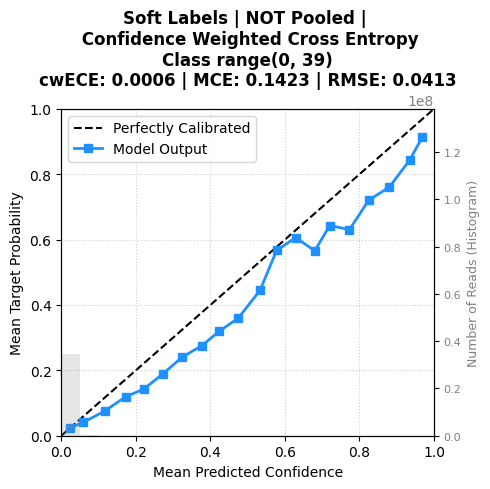

In [80]:
plot_reliability_diagrams(res_cwce_wp[0], res_cwce_wp[1], [range(39)], labels_dict=labels_dict, main_title="Soft Labels | NOT Pooled | \n Confidence Weighted Cross Entropy",n_bins=20)

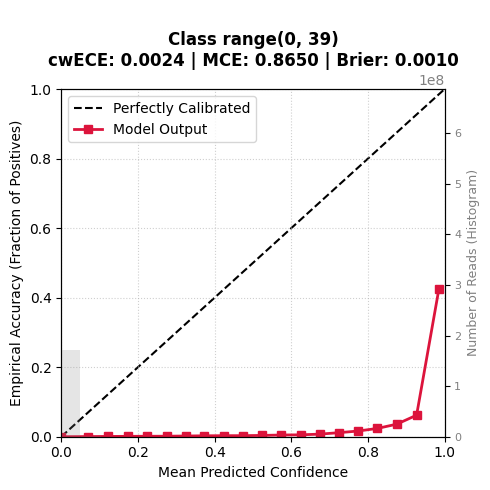

In [76]:
plot_hard_reliability_diagrams(res_ce_hard[0], res_ce_hard[1],[range(39)],labels_dict,20)

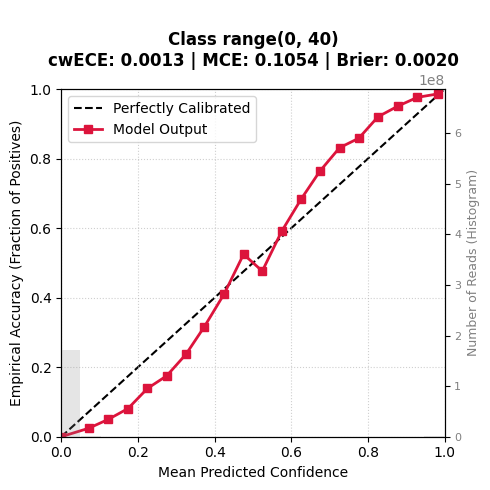

In [82]:
plot_hard_reliability_diagrams(res_ce_hard[0], res_ce_hard[1],[range(40)],labels_dict,20)

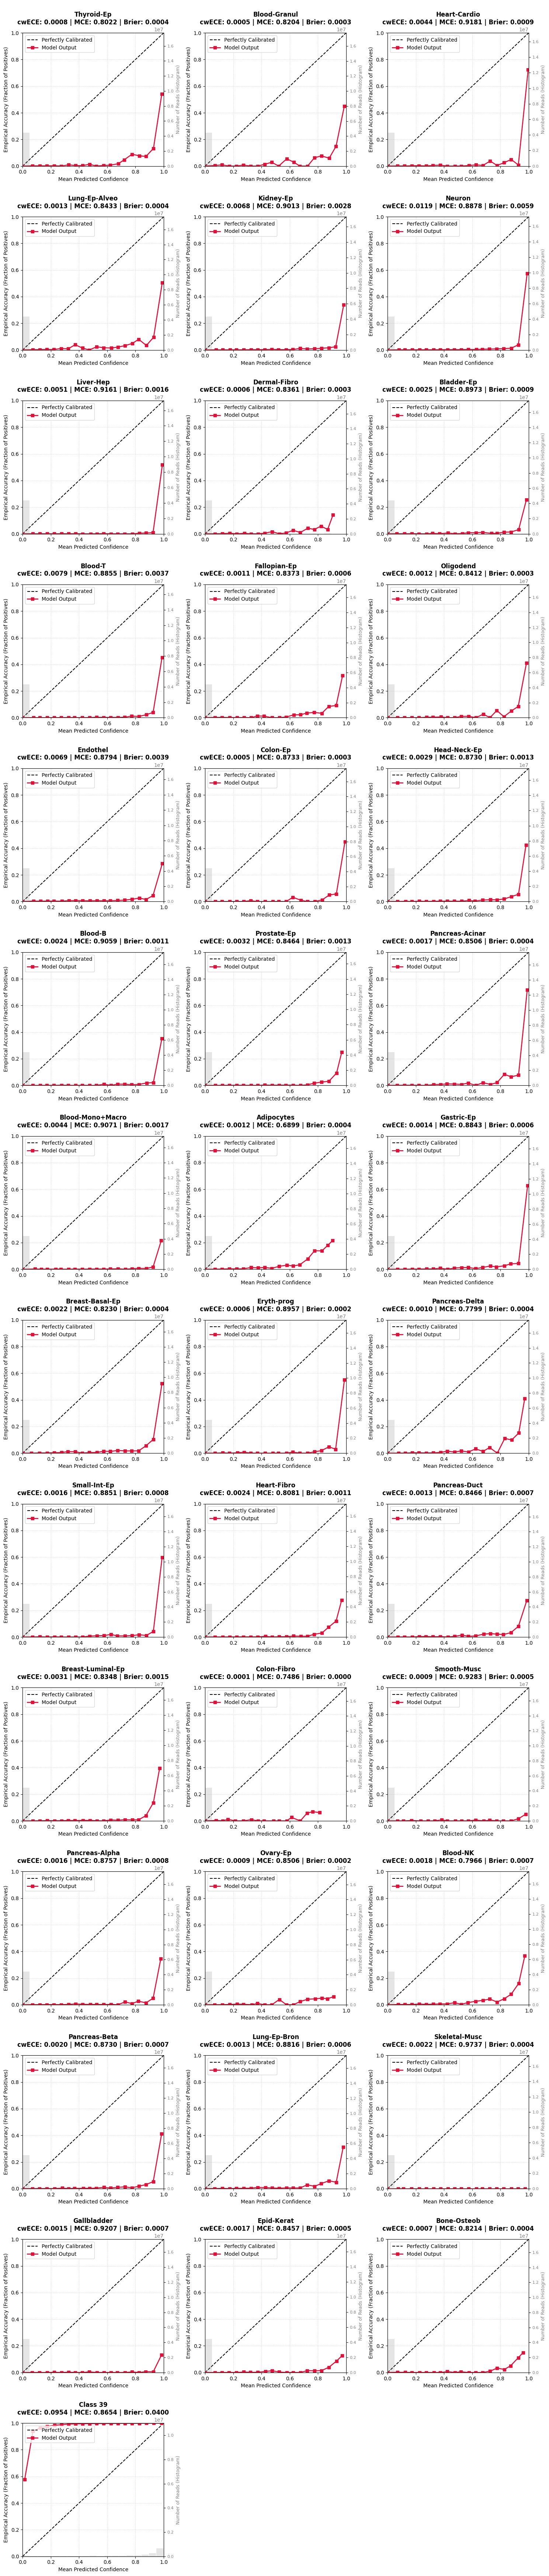

In [81]:
plot_hard_reliability_diagrams(res_ce_hard[0], res_ce_hard[1],list(range(40)),labels_dict,20)